In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, GlobalAvgPool2D, Flatten, MaxPooling2D, Input, Dropout, BatchNormalization, Activation, GlobalAveragePooling2D
from keras.models import Sequential

In [2]:
train_data = keras.preprocessing.image_dataset_from_directory(
    "Images\Training",
    color_mode="rgb",
    image_size=(224,224),
    batch_size=16)

test_data = keras.preprocessing.image_dataset_from_directory(
    "Images\Testing",
    color_mode="rgb",
    image_size=(224,224),
    batch_size=16)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [3]:
class_name = train_data.class_names

In [4]:
normalization_layer = keras.layers.Rescaling(1./255)
train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
test_data = test_data.map(lambda x, y: (normalization_layer(x), y))

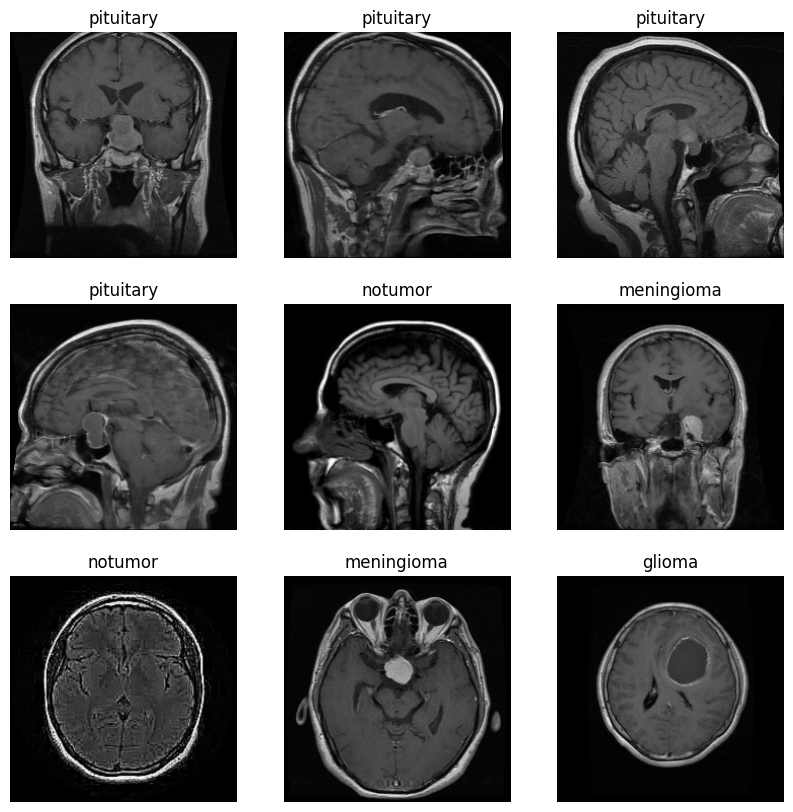

In [5]:
batch = train_data.as_numpy_iterator().next()
plt.figure(figsize=(10,10))
for i in range(1,10):
    plt.subplot(3,3,i)
    plt.imshow(batch[0][i])
    plt.title(class_name[batch[1][i]])
    plt.axis(False)
    
plt.savefig("Sample_Images.png")
plt.show()

In [6]:
data_augmentation = Sequential([
    keras.layers.Rescaling(1./255),              
    keras.layers.RandomFlip("horizontal"),       
    keras.layers.RandomRotation(0.1),            
    keras.layers.RandomZoom(0.1)              
 ])

In [7]:
from tensorflow.keras.regularizers import l2

model = Sequential([
    Input(shape=(224, 224, 3)),

    data_augmentation,  # ✅ Enable augmentation

    # Block 1
    Conv2D(32, (3,3), padding="same", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), padding="same", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128, (3,3), padding="same", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D((2,2)),

    # Block 4
    Conv2D(256, (3,3), padding="same", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D((2,2)),

    # Block 5 — extra depth
    Conv2D(512, (3,3), padding="same", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(256, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.5),

    Dense(128, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.4),

    Dense(4, activation="softmax")
])

In [8]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 14, 14, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │              

 Total params: 1,738,820 (6.63 MB)

 Trainable params: 1,736,068 (6.62 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [9]:
callbacks = [
    # Reduce LR on plateau
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.5,
        min_lr=1e-6,
        verbose=1
    ),

    # Early stopping
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    # Save best model
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    # TensorBoard logging
    keras.callbacks.TensorBoard(
        log_dir="./logs",
        histogram_freq=1
    )
]

In [10]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_accuracy")  
    ]
)

In [11]:
history = model.fit(
    train_data,
    epochs=50,
    validation_data=test_data,
    callbacks=callbacks,
)

Epoch 1/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5767 - loss: 2.1875 - top2_accuracy: 0.8069
Epoch 1: val_accuracy improved from -inf to 0.25000, saving model to best_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 671s 2s/step - accuracy: 0.5769 - loss: 2.1870 - top2_accuracy: 0.8071 - val_accuracy: 0.2500 - val_loss: 2.8732 - val_top2_accuracy: 0.5013 - learning_rate: 0.0010
Epoch 2/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6993 - loss: 1.5688 - top2_accuracy: 0.8973
Epoch 2: val_accuracy did not improve from 0.25000
350/350 ━━━━━━━━━━━━━━━━━━━━ 659s 2s/step - accuracy: 0.6994 - loss: 1.5684 - top2_accuracy: 0.8973 - val_accuracy: 0.2500 - val_loss: 3.8465 - val_top2_accuracy: 0.5000 - learning_rate: 0.0010
Epoch 3/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7561 - loss: 1.2150 - top2_accuracy: 0.9269
Epoch 3: val_accuracy did not improve from 0.25000
350/350 ━━━━━━━━━━━━━━━━━━━━ 586s 2s/step - accuracy: 0.7561 - loss: 1.2148 - top2_accuracy: 0.92

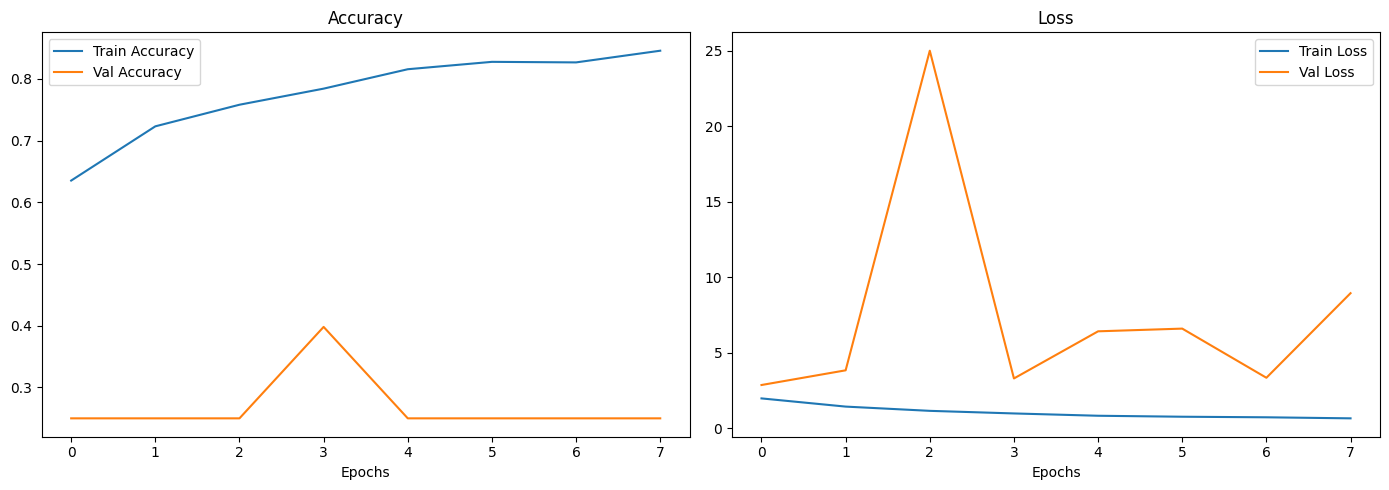

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epochs")
axes[0].legend()

# Loss
axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
prediction = model.predict(test_data)

100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step


In [14]:
import joblib 

In [15]:
joblib.dump(model, "model.pkl")

['model.pkl']

In [24]:
model.save("model_h5.h5")

In [26]:
model.save("model_keras.keras")

In [16]:
import glob
import random
paths =glob.glob(r"C:\Users\PAWAN\DS\DATA SCIENCE\Projects\Medical Image Classification\Images\Testing\*\*.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
C:\Users\PAWAN\DS\DATA SCIENCE\Projects\Medical Image Classification\Images\Testing\glioma\Te-gl_202.jpg
Prediction: pituitary
confidance: 62.36


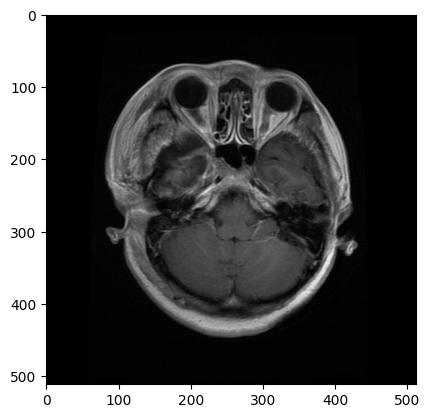

In [23]:
r = random.randint(0,len(paths))

img = keras.utils.load_img(paths[r])
arr_img = keras.utils.img_to_array(img)
arr_img = np.resize(arr_img, (224,224,3))
plt.imshow(img)
# plt.imshow(arr_img)
arr_img = arr_img/255
arr_img = np.expand_dims(arr_img, axis=0)
prediction=model.predict(arr_img)
classes = np.argmax(prediction)
confidance = np.max(prediction)


print(paths[r])
print(f"Prediction: {class_name[classes]}")
print(f"confidance: {(confidance*100).round(2)}")

In [18]:
arr_img.shape

(1, 224, 224, 3)

In [19]:
classes = np.argmax(prediction)
class_name[classes]

'pituitary'

In [20]:
len(paths)

1600